<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

## **Proyecto Tutorial K-Medias**

**Autora:** Anais Aponte  
**Bootcamp:** 4Geeks Academy – Intro to Machine Learning  
**Proyecto:** Proyecto Tutorial K-Medias  

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Instrucciones**

#### **Sistema de agrupación de casas**

El objetivo es clasificar casas según la región en la que se encuentren y del ingreso medio.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### 📝 **Paso 1: Carga del conjunto de datos**

El dataset utilizado en este proyecto es **housing.csv**.

Para facilitar la reproducibilidad y evitar dependencias externas, el archivo ha sido previamente descargado y almacenado dentro del repositorio en la siguiente ruta:

📁 `data/raw/housing.csv`

De esta forma, el notebook puede ejecutarse directamente sin necesidad de acceder a enlaces externos.

A continuación se realizan primero las importaciones necesarias y, posteriormente, la carga del dataset para iniciar el análisis.

</div>

In [26]:
# Manipulación de datos
import pandas as pd
# Preprocesamiento
from sklearn.preprocessing import StandardScaler
# División de datos
from sklearn.model_selection import train_test_split
# Modelos
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
# Métricas
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Graficos
import seaborn as sns
import matplotlib.pyplot as plt
# Importamos la librería para guardar modelos
import joblib

In [2]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR
df = pd.read_csv('../data/raw/housing.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación inicial**

En este dataset se identifican 9 variables numéricas que representan características demográficas y estructurales asociadas a cada grupo de viviendas en California.

Siguiendo las indicaciones del proyecto, las variables más relevantes para el análisis serán: `Latitude`, `Longitude` y `MedInc`.  

- `Latitude` y `Longitude` permiten ubicar geográficamente cada registro dentro del estado de California.  
- `MedInc` representa el ingreso medio de los habitantes de la zona, lo cual puede influir directamente en la agrupación de las viviendas.

Dado que se trata de un problema de aprendizaje no supervisado el objetivo es descubrir patrones o agrupaciones (clusters) de forma automática sin una variable a predecir.


</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 1.1: Seleccionar las variables**

</div>

In [3]:
# Seleccionamos SOLO las variables que vamos a usar
X = df[['Latitude', 'Longitude', 'MedInc']]
X

,Latitude,Longitude,MedInc
0,37.88,-122.23,8.3252
1,37.86,-122.22,8.3014
2,37.85,-122.24,7.2574
3,37.85,-122.25,5.6431
4,37.85,-122.25,3.8462
...,...,...,...
20635,39.48,-121.09,1.5603
20636,39.49,-121.21,2.5568
20637,39.43,-121.22,1.7000
20638,39.43,-121.32,1.8672


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 1.2: Separar train y test**

</div>

In [4]:
# Separamos variables 
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 🔹 Separación de variables

Dado que se trata de un problema de aprendizaje no supervisado, no existe una variable objetivo (`y`).  

Por lo tanto, se trabajará únicamente con las variables seleccionadas (`Latitude`, `Longitude`, `MedInc`), agrupándolas en `X`.

</div>

------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 2: Construye un K-Means**

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.1: Escalado de variables**

</div>

In [5]:
# Inicializamos el scaler para estandarizar los datos (media 0, desviación estándar 1)
scaler = StandardScaler()

# Ajustamos el scaler solo con los datos de entrenamiento y transformamos train y test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
X_train_scaled

array([[-1.3728112 ,  1.27258656, -0.326196  ],
       [-0.87669601,  0.70916212, -0.03584338],
       [-0.46014647, -0.44760309,  0.14470145],
       ...,
       [-0.75500738,  0.59946887, -0.49697313],
       [ 0.90651045, -1.18553953,  0.96545045],
       [ 0.99543676, -1.41489815, -0.68544764]], shape=(16512, 3))

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Nota: Elección de la técnica de escalado**

Se utiliza la técnica de estandarización (`StandardScaler`) porque transforma las variables para que tengan media 0 y desviación estándar 1, manteniendo la forma original de la distribución de los datos.

Esta técnica es especialmente adecuada en este caso, ya que no conocemos a priori la distribución de las variables (`Latitude`, `Longitude`, `MedInc`) ni si contienen valores atípicos significativos, por lo que resulta una opción robusta y general.

Además, al tratarse de un modelo basado en distancias como K-Means, es importante que todas las variables contribuyan de manera equilibrada al cálculo de la distancia, sin que ninguna domine por su escala original.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.2: Creación y entrenamiento del modelo**

</div>

In [7]:
#Creamos el k-Means para los 6 clusters solicitados
kmeans = KMeans(n_clusters = 6, init = 'k-means++', random_state = 42) #k-means++ acelera la convergencia, respecto de random

# Entrenamos el modelo K-Means con los datos de entrenamiento y asignamos a cada observación su cluster correspondiente
y_kmeans = kmeans.fit_predict(X_train_scaled)

# Mostramos los cluster 
y_kmeans

array([3, 3, 1, ..., 3, 0, 5], shape=(16512,), dtype=int32)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.3: Añadir variable cluster**

</div>

In [8]:
# Creamos una copia del conjunto de test para no modificar el original
X_train_clustered = X_train.copy()

# Añadimos la etiqueta de cluster asignada por K-Means a cada registro del conjunto de entrenamiento
X_train_clustered['cluster'] = y_kmeans

X_train_clustered

,Latitude,Longitude,MedInc,cluster
14196,32.71,-117.03,3.2596,3
8267,33.77,-118.16,3.8125,3
17445,34.66,-120.48,4.1563,1
14265,32.69,-117.11,1.9425,3
2271,36.78,-119.80,3.5542,5
...,...,...,...,...
11284,33.78,-117.96,6.3700,1
11964,34.02,-117.43,3.0500,3
5390,34.03,-118.38,2.9344,3
860,37.58,-121.96,5.7192,0


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 2.4: Analizar los cluster**

</div>

In [9]:
X_train_clustered.groupby(['cluster']).mean(numeric_only=True)

,Latitude,Longitude,MedInc
cluster,,,
0,37.737846,-121.960825,5.370513
1,33.872459,-118.028568,5.225473
2,34.885155,-119.218137,10.305096
3,33.926440,-117.925894,2.720662
4,39.623350,-122.385193,2.406233
5,37.553819,-121.261056,2.816021


<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Observación inicial de clusters**

A partir de la media de las variables, se observa que el **cluster 2** presenta el mayor nivel de ingresos (`MedInc ≈ 10.30`), lo que sugiere que agrupa las zonas más exclusivas del dataset.

Por el contrario, el **cluster 4** muestra el menor nivel de ingresos (`MedInc ≈ 2.40`), representando áreas con menores recursos.

A continuación, se analizará el tamaño de cada cluster para entender mejor su representatividad dentro del conjunto de datos.

</div>

In [10]:
# Número de observaciones por cluster
X_train_clustered['cluster'].value_counts()

cluster
3    5421
5    3598
1    3554
0    2474
4     982
2     483
Name: count, dtype: int64

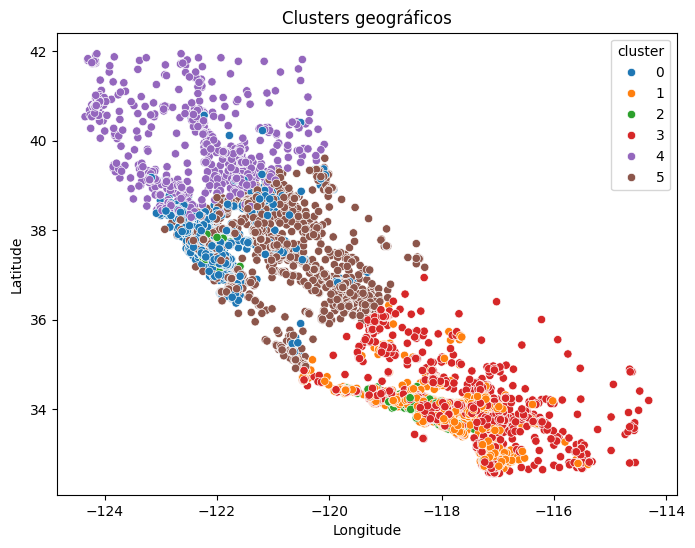

In [11]:
# Visualizamos clusters en el mapa
plt.figure(figsize=(8,6))
sns.scatterplot(data=X_train_clustered, x='Longitude', y='Latitude', hue='cluster', palette='tab10')
plt.title('Clusters geográficos')
plt.show()

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Interpretación de clusters**

A partir de la visualización geográfica, se observa que los clusters se agrupan claramente por zonas dentro del estado de California, lo que indica que el modelo ha capturado patrones espaciales relevantes.

Los clusters con mayor número de observaciones (como el 3, 5 y 1) representan las áreas más densamente pobladas, mientras que los clusters 2 y 4, que presentan menor tamaño, corresponden a zonas más específicas o menos representativas dentro del dataset. 

Se observa que el cluster 2, correspondiente a las zonas con mayor nivel de ingresos, presenta una mayor dispersión geográfica en comparación con otros clusters.  Esto indica que las áreas con alta capacidad adquisitiva no se concentran en una única región, sino que están distribuidas en diferentes zonas del estado.

Este comportamiento refleja que el modelo no solo agrupa por proximidad geográfica, sino también por similitud en características socioeconómicas como el ingreso medio.

En general, se aprecia una separación geográfica coherente entre los clusters, lo que sugiere que la localización juega un papel importante en la segmentación de las viviendas.

</div>

<div style="background-color:#E8F6F3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 💡 **Conclusión del modelo**

El modelo K-Means ha logrado segmentar las viviendas en grupos coherentes tanto a nivel geográfico como socioeconómico, identificando zonas con distintos niveles de ingresos y densidad de observaciones.

Esto confirma que las variables seleccionadas (`Latitude`, `Longitude`, `MedInc`) son relevantes para capturar patrones significativos en el dataset.

</div>

-------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 3: Predice con el conjunto de test**

</div>

In [12]:
# Predecimos los clusters del conjunto de test usando el modelo ya entrenado
y_test_kmeans = kmeans.predict(X_test_scaled)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 3.1: Visualizamos la prediccion con los datos de test**

</div>

In [13]:
# Creamos una copia del conjunto de test para no modificar el original
X_test_clustered = X_test.copy()

# Añadimos la etiqueta de cluster predicha por el modelo
X_test_clustered['cluster'] = y_test_kmeans

X_test_clustered


,Latitude,Longitude,MedInc,cluster
20046,36.06,-119.01,1.6812,3
3024,35.14,-119.46,2.5313,3
15663,37.80,-122.44,3.4801,5
20484,34.28,-118.72,5.7376,1
9814,36.62,-121.93,3.7250,5
...,...,...,...,...
15362,33.36,-117.22,4.6050,1
16623,35.36,-120.83,2.7266,5
18086,37.31,-122.05,9.2298,2
2144,36.77,-119.76,2.7850,5


<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 3.1: Graficamos tanto train como test**

</div>

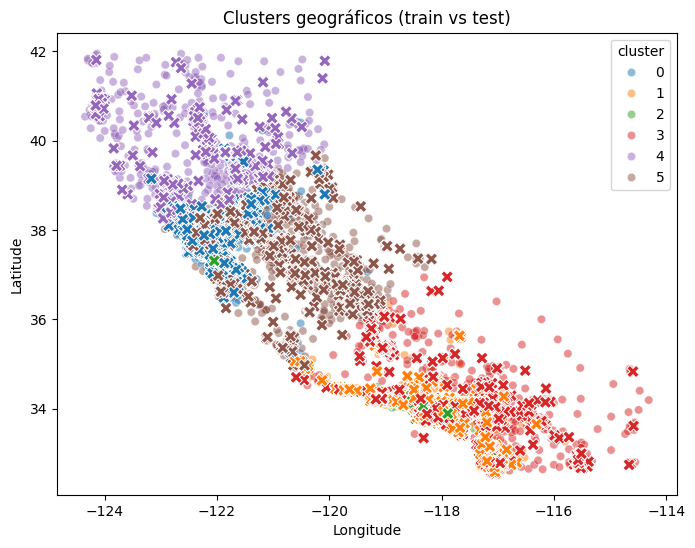

In [14]:
# Visualizamos los clusters del conjunto de entrenamiento y añadimos los puntos del test para comprobar la coherencia del modelo
plt.figure(figsize=(8,6))

# Train (más transparente)
sns.scatterplot(data=X_train_clustered, x='Longitude', y='Latitude', hue='cluster', palette='tab10', alpha=0.5)

# Test (encima, más visible)
sns.scatterplot(data=X_test_clustered, x='Longitude', y='Latitude', hue='cluster', palette='tab10', marker='X', s=80, legend=False)

plt.title('Clusters geográficos (train vs test)')
plt.show()

<div style="background-color:#fff3cd; border-left:6px solid #f1c40f; padding:15px; border-radius:8px; color:#1b1b1b;">

### 💡 **Validación del modelo con datos de test**

Al superponer los datos del conjunto de test sobre los clusters obtenidos con el conjunto de entrenamiento, se observa que los nuevos puntos se integran de forma coherente dentro de las estructuras previamente identificadas.

Los clusters mantienen una distribución geográfica consistente, lo que indica que el modelo ha aprendido patrones generalizables y es capaz de asignar correctamente nuevas observaciones.

Destaca que el cluster asociado a mayores ingresos presenta una mayor dispersión geográfica, lo que sugiere que este grupo responde más a un perfil socioeconómico que a una localización concreta.

En conjunto, la predicción puede considerarse satisfactoria, ya que no se observan desviaciones significativas ni comportamientos anómalos en los datos de test.

</div>

------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 4: Entrena un modelo de clasificación supervisada: KNN**

</div>

<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

#### 💡 **Elección del modelo supervisado**

Se ha seleccionado el algoritmo de **K vecinos más cercanos (KNN)** para predecir la variable `cluster`, ya que, al igual que K-Means, se basa en el cálculo de distancias entre observaciones.

Dado que los clusters fueron generados mediante un método basado en distancias y las variables han sido previamente estandarizadas, KNN resulta coherente y adecuado para replicar la asignación de grupos en nuevas observaciones.

</div>

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 4.1: Separar X y y**

</div>

In [ ]:
# Definimos variables predictoras y objetivo
X = X_train_clustered[['Latitude', 'Longitude', 'MedInc']]
y = X_train_clustered['cluster']

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 4.2: Train / Test split (80/20)**

</div>

In [21]:
# Dividimos datos para el modelo supervisado
X_train_sup, X_test_sup, y_train_sup, y_test_sup = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 4.3: Escalar Train y Test**

</div>

In [22]:
# Inicializamos el scaler
scaler = StandardScaler()

# Ajustamos solo con train y transformamos ambos conjuntos
X_train_sup_scaled = scaler.fit_transform(X_train_sup)
X_test_sup_scaled = scaler.transform(X_test_sup)

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

#### **Paso 4.4: Entrenar modelo supervisado -> Busqueda del k optimo**

</div>

In [24]:
# Probamos distintos valores de K y guardamos la precisión obtenida en cada caso para identificar el mejor valor
k_values = range(1, 21)
accuracy_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_sup_scaled, y_train_sup)
    y_pred_k = model.predict(X_test_sup_scaled)
    acc = accuracy_score(y_test_sup, y_pred_k)
    accuracy_scores.append(acc)

# Mostramos la precisión obtenida para cada valor de K
for k, acc in zip(k_values, accuracy_scores):
    print(f"K = {k}: Accuracy = {acc:.4f}")

K = 1: Accuracy = 0.9873
K = 2: Accuracy = 0.9855
K = 3: Accuracy = 0.9897
K = 4: Accuracy = 0.9873
K = 5: Accuracy = 0.9900
K = 6: Accuracy = 0.9888
K = 7: Accuracy = 0.9912
K = 8: Accuracy = 0.9906
K = 9: Accuracy = 0.9897
K = 10: Accuracy = 0.9894
K = 11: Accuracy = 0.9882
K = 12: Accuracy = 0.9888
K = 13: Accuracy = 0.9870
K = 14: Accuracy = 0.9870
K = 15: Accuracy = 0.9864
K = 16: Accuracy = 0.9843
K = 17: Accuracy = 0.9849
K = 18: Accuracy = 0.9855
K = 19: Accuracy = 0.9837
K = 20: Accuracy = 0.9840


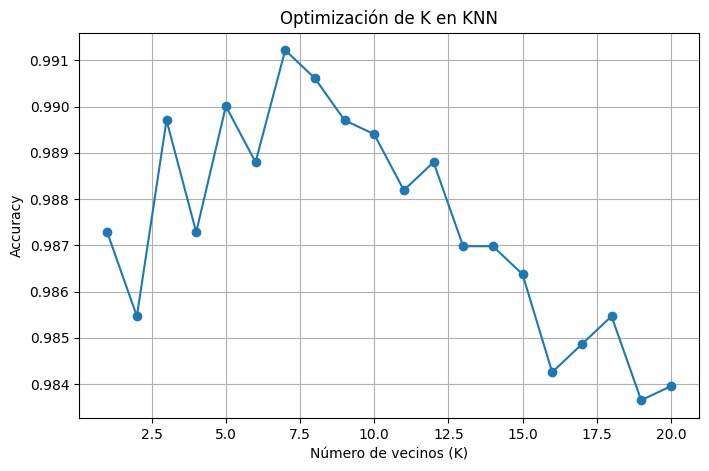

In [25]:
# Representamos gráficamente la accuracy obtenida para cada valor de K para identificar el valor óptimo
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel('Número de vecinos (K)')
plt.ylabel('Accuracy')
plt.title('Optimización de K en KNN')
plt.grid()
plt.show()

In [32]:
# Entrenamos el modelo KNN final con el mejor valor de K encontrado
best_k = k_values[accuracy_scores.index(max(accuracy_scores))]
print(f"Mejor K: {best_k}")
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_sup_scaled, y_train_sup)

Mejor K: 7


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Evaluación de K en KNN y planteamiento de mejora**

Al evaluar distintos valores de K, se observa que el modelo KNN alcanza valores de accuracy muy elevados en prácticamente todos los casos, lo que indica que la estructura de los datos es fácilmente separable.

Este comportamiento es esperable, ya que el modelo está aprendiendo a replicar los clusters previamente generados por K-Means, ambos basados en el cálculo de distancias, lo que facilita la clasificación.

Sin embargo, dado que tanto K-Means como KNN se basan en el cálculo de distancias, resulta interesante evaluar un modelo alternativo que no dependa de esta lógica, como **Random Forest**.

De este modo, se puede comprobar si la estructura de los datos puede ser aprendida también mediante reglas de decisión más complejas, aportando una validación adicional sobre la calidad de los clusters generados.


</div>

------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 5: Entrenar un segundo modelo supervisado: Random Forest**

</div>

In [28]:
# Inicializamos y entrenamos el modelo Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_sup, y_train_sup)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
# Predecimos los clusters en el conjunto de test
y_pred_rf = rf_model.predict(X_test_sup)

In [30]:
# Calculamos la accuracy del modelo
acc_rf = accuracy_score(y_test_sup, y_pred_rf)
print(f"Accuracy Random Forest: {acc_rf:.4f}")

Accuracy Random Forest: 0.9930


In [31]:
# Mostramos métricas de clasificación por clase
print(classification_report(y_test_sup, y_pred_rf))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       495
           1       1.00      0.99      1.00       711
           2       0.99      0.98      0.98        97
           3       1.00      1.00      1.00      1084
           4       0.98      0.99      0.98       196
           5       0.99      0.99      0.99       720

    accuracy                           0.99      3303
   macro avg       0.99      0.99      0.99      3303
weighted avg       0.99      0.99      0.99      3303



<div style="background-color:#fff3cd; padding:20px; border-left:8px solid #ffcc00; border-radius:8px; color:#1b1b1b;">

### 💡 **Resultados del modelo Random Forest**

El modelo Random Forest obtiene valores de accuracy muy elevados, similares a los obtenidos con KNN, lo que indica que la estructura de los datos es fácilmente aprendible.

Este comportamiento se debe a que los clusters utilizados como variable objetivo han sido previamente generados por K-Means, lo que implica que los datos ya se encuentran organizados en grupos bien definidos.

En este contexto, el modelo supervisado no está descubriendo nuevos patrones, sino aprendiendo a reproducir una estructura previamente establecida, lo que explica el alto rendimiento obtenido.

</div>

------

<div style="background-color:#d6eaff; border-left:6px solid #4a90e2; padding:15px; border-radius:8px; color:#1b1b1b;">

### **Paso 6: Guardar los modelos**

</div>

In [34]:
# Guardamos los modelos entrenados y el scaler para poder reutilizarlos posteriormente

joblib.dump(kmeans, '../models/kmeans_model.sav')
joblib.dump(knn_model, '../models/knn_model.sav')
joblib.dump(rf_model, '../models/rf_model.sav')
joblib.dump(scaler, '../models/california_housing_clustering_scaler.sav')

['../models/california_housing_clustering_scaler.sav']

<div style="background-color:#d5f5e3; padding:20px; border-left:8px solid #27AE60; border-radius:8px; color:#1b1b1b;">

### 🚀 **Conclusión final del proyecto**

Los resultados obtenidos muestran valores de accuracy muy elevados en ambos modelos, lo que indica que los clusters generados presentan fronteras bien definidas y son fácilmente separables. Este comportamiento es esperable, dado que los modelos supervisados están aprendiendo a reproducir una estructura previamente generada por un algoritmo no supervisado.

En conclusión, el proyecto demuestra cómo combinar modelos de aprendizaje no supervisados y supervisados para descubrir patrones en los datos y aplicar ese conocimiento a nuevas observaciones.

</div>